# 📈 Cryptocurrency Price Forecasting
### Capstone Project — Comparing MLP vs LSTM on Bitcoin Daily Data

---

| | |
|---|---|
---

> **Objective:** To forecast the next-day closing price of Bitcoin using historical daily market data from January 2019 to August 2023, by implementing and comparing two deep learning architectures — a Multi-Layer Perceptron (MLP) and a Long Short-Term Memory (LSTM) network — and evaluating which model better captures the time-dependent patterns in a highly volatile financial series.

---

<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Project Snapshot:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Parameter</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Value</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Dataset</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Bitcoin_Daily.csv (1,674 daily records, 2019–2023)</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Target Variable</b></td>
    <td style="padding:8px; border:1px solid #ddd;"><code>close</code> — daily closing price of Bitcoin (USD)</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Models Compared</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Multi-Layer Perceptron (MLP), Long Short-Term Memory (LSTM)</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Forecasting Horizon</b></td>
    <td style="padding:8px; border:1px solid #ddd;">One day ahead (next-day closing price)</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Lookback Window</b></td>
    <td style="padding:8px; border:1px solid #ddd;">30 days (SEQ_LEN = 30)</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Train / Test Split</b></td>
    <td style="padding:8px; border:1px solid #ddd;">80% train / 20% test (chronological)</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Frameworks</b></td>
    <td style="padding:8px; border:1px solid #ddd;">PyTorch, scikit-learn, pandas, NumPy, Matplotlib</td>
  </tr>
</table>
</div>

---

# 1. Problem Statement and Business Context

## 1.1 The Forecasting Problem

We aim to predict the **next-day closing price of Bitcoin** using the previous 30 days of closing prices as input. Given a sequence of 30 historical daily closing prices, the model outputs a single prediction: the closing price for the following day. This is a univariate, single-step time-series regression problem.

## 1.2 Why This Problem Matters

Cryptocurrency markets, and Bitcoin in particular, are characterized by extreme volatility and round-the-clock trading. Daily price moves of more than 10 percent are not unusual, and the market is sensitive to sentiment, regulation, and macroeconomic events. For market participants, this volatility creates a need for forward-looking estimates of price levels, even modest ones, to inform decisions around portfolio sizing, trade timing, and risk management.

A reliable next-day price forecast — even one with imperfect accuracy — has direct applications in:

- **Portfolio risk management** — sizing positions based on expected price ranges.
- **Trade execution timing** — informing entry and exit windows.
- **Trend reversal detection** — flagging conditions where predicted direction diverges from recent momentum.

## 1.3 Modeling Approach

We compare two deep learning architectures:

- **Multi-Layer Perceptron (MLP)** — a feedforward neural network that treats the 30-day input as a flat list of values, with no awareness of the order between them.
- **Long Short-Term Memory (LSTM)** — a recurrent neural network that processes the 30-day input as an ordered sequence, maintaining an internal state that propagates information across time steps.

The central question is whether explicit sequence-awareness, as in the LSTM, translates into measurable forecasting improvement over the order-blind MLP on this dataset.

---

<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Why this framing matters:</b> By scoping the problem clearly upfront — one input variable, one-step horizon, two specific architectures — we ensure that the comparison between MLP and LSTM is a clean, controlled test of sequence-awareness rather than a comparison confounded by other modeling choices.
</div>

---

# 2. Library Imports & Setup

This section installs and imports all libraries required for the project, and configures reproducibility settings so that results remain consistent across runs.

In [1]:
!pip install torch

In [2]:
# Install required libraries
# Foundational libraries first (numpy, pandas), then visualization, then ML/DL
!pip install numpy pandas
!pip install matplotlib
!pip install scikit-learn
!pip install torch

In [3]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Deep learning framework
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully.
PyTorch version: 2.11.0+cpu


In [4]:
# Set random seeds for reproducibility
# This ensures that running the notebook again produces identical results
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Library Roles in This Project:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Library</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Purpose in This Project</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>pandas</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Loading the Bitcoin CSV file and handling the data as a table</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>NumPy</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Numerical arrays and mathematical operations underlying all data processing</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Matplotlib</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Plotting closing price trends, moving averages, and Actual vs Predicted comparisons</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>scikit-learn</b></td>
    <td style="padding:8px; border:1px solid #ddd;">MinMaxScaler for normalizing prices to [0,1], and metric functions for MSE and MAE</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>PyTorch</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Building the MLP and LSTM architectures, training loops, and prediction</td>
  </tr>
</table>
<br>
<b>🔁 Reproducibility:</b> A fixed random seed (42) is applied to NumPy and PyTorch to ensure consistent results across runs. This is a standard practice in deep learning to allow others to verify the same numerical outputs.
</div>

# 3. Loading the Dataset & First Look

We begin by loading the Bitcoin daily price dataset and inspecting its structure to confirm the data has been read correctly and aligns with the brief's specifications.

In [5]:
# Load the Bitcoin daily price dataset
# parse_dates ensures the timestamp column is read as datetime objects, not plain text
df = pd.read_csv('Bitcoin_Daily.csv', parse_dates=['timestamp'])

# Display the first 5 rows to confirm the data loaded as expected
df.head()

,timestamp,open,high,low,close,volume
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,29493.893940
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>📌 Initial Observation:</b> The dataset has been loaded successfully and contains six columns matching the brief's specifications — <code>timestamp</code>, <code>open</code>, <code>high</code>, <code>low</code>, <code>close</code>, and <code>volume</code>. The earliest dates in the preview show January 2019, which aligns with the expected starting period of the dataset.<br><br>
For this project, only the <b><code>close</code></b> column will be used as both input (via 30-day windows) and target (next-day prediction), as specified in the project brief.
</div>

In [6]:
# Check the dataset's shape (rows, columns) and the date range it covers
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range:    {df['timestamp'].min().date()}  to  {df['timestamp'].max().date()}")
print(f"Total days:    {(df['timestamp'].max() - df['timestamp'].min()).days + 1} calendar days")

Dataset shape: 1674 rows x 6 columns
Date range:    2019-01-01  to  2023-08-01
Total days:    1674 calendar days


<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>📌 Dataset Coverage:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#4CAF50; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Property</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Value</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Total observations</b></td>
    <td style="padding:8px; border:1px solid #ddd;">1,674 daily records</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Date range</b></td>
    <td style="padding:8px; border:1px solid #ddd;">January 1, 2019 — August 1, 2023</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Frequency</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Daily (no missing dates — Bitcoin trades 24/7)</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Columns</b></td>
    <td style="padding:8px; border:1px solid #ddd;">6 (timestamp, open, high, low, close, volume)</td>
  </tr>
</table>
<br>
<b>📌 Market Context:</b> This time window covers several distinct market regimes — the early 2019 recovery, the COVID-19 crash of March 2020, the 2021 bull run reaching an all-time high near $69,000, and the 2022 bear market triggered by macroeconomic tightening and the collapses of major crypto entities (Luna, FTX). This gives the models exposure to a wide range of market behaviors.
</div>

# 4. Data Quality Checks

Before proceeding with analysis and modeling, we verify the integrity of the dataset by checking for missing values, confirming data types, and identifying any duplicate records.

In [7]:
# Check 1: Data types of each column
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

# Check 2: Missing values per column
print("\n" + "=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

# Check 3: Duplicate timestamps
print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")
print(f"Fully duplicated rows: {df.duplicated().sum()}")

# Check 4: Quick statistical summary of numerical columns
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

DATA TYPES
timestamp    datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume              float64
dtype: object

MISSING VALUES PER COLUMN
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

DUPLICATES
Duplicate timestamps: 0
Fully duplicated rows: 0

STATISTICAL SUMMARY


,timestamp,open,high,low,close,volume
count,1674,1674.000000,1674.000000,1674.000000,1674.000000,1674.000000
mean,2021-04-16 12:00:00,23826.260191,24446.346302,23141.704301,23841.391380,90492.866809
min,2019-01-01 00:00:00,3398.400000,3426.450000,3349.920000,3398.400000,10851.368440
25%,2020-02-23 06:00:00,9390.600000,9588.250000,9211.455000,9396.917500,37840.367112
50%,2021-04-16 12:00:00,20018.950000,20424.090000,19544.545000,20043.810000,56891.096851
75%,2022-06-08 18:00:00,36009.072500,37542.552500,34395.287500,36009.072500,93691.800425
max,2023-08-01 00:00:00,67525.820000,69000.000000,66222.400000,67525.830000,760705.362783
std,NaN,16474.464732,16932.258079,15937.256978,16467.689321,93496.285584


<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>📌 Data Quality Findings:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#4CAF50; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Check</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Result</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Missing values</b></td>
    <td style="padding:8px; border:1px solid #ddd;">None — all 1,674 rows are complete across all columns ✅</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Data types</b></td>
    <td style="padding:8px; border:1px solid #ddd;">timestamp is datetime; OHLCV columns are numeric (float64) ✅</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Duplicates</b></td>
    <td style="padding:8px; border:1px solid #ddd;">No duplicate timestamps and no duplicate rows ✅</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Statistical summary</b></td>
    <td style="padding:8px; border:1px solid #ddd;">close ranges from ~$3,400 (2019 low) to ~$67,500 (2021 ATH); mean ≈ $23,800</td>
  </tr>
</table>
<br>
<b>📌 Conclusion:</b> The dataset is clean and requires no preprocessing for missing values or duplicates. We can proceed directly to exploratory data analysis.<br><br>
<b>Note:</b> Had missing values been present, they would typically be handled using <code>df.fillna(method='ffill')</code> (forward-fill) for time-series data, since consecutive daily prices are highly correlated. For larger gaps, interpolation or removal would be considered based on context.
</div>

# 5. Exploratory Data Analysis (EDA)

This section explores the structure and behavior of Bitcoin's daily closing price across the 2019–2023 period. We visualize the price trend, compute moving averages to identify momentum patterns, and discuss the major market events visible in the data.

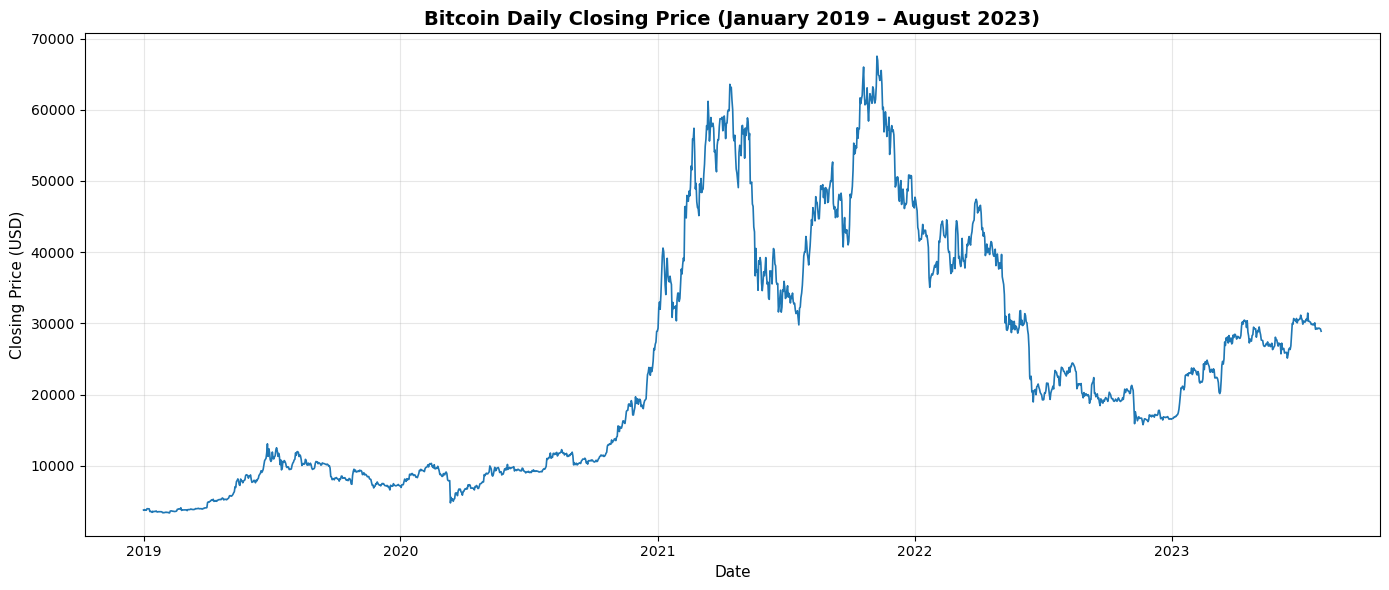

In [8]:
# Plot the daily closing price trend across the full dataset period
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['close'], color='#1f77b4', linewidth=1.2)

# Chart formatting
plt.title('Bitcoin Daily Closing Price (January 2019 – August 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Closing Price (USD)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>📌 What This Chart Shows:</b> Bitcoin's daily closing price across the full study period reveals four distinct market phases:<br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#4CAF50; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Period</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Behavior</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>2019 – early 2020</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Recovery phase — price rises gradually from ~$3,800 to around $10,000</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>March 2020</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Sharp crash — COVID-19 pandemic triggers a market-wide sell-off; price drops to ~$5,000 in days</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Mid-2020 – November 2021</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Bull run — price climbs steeply, reaching an all-time high near $69,000</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>2022 – 2023</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Bear market — sustained decline to ~$16,000 (late 2022) followed by partial recovery to ~$29,000 by August 2023</td>
  </tr>
</table>
<br>
<b>📌 Implication for Modeling:</b> The price series clearly does not behave like a stable, predictable signal. Its average level changes by nearly 20× across the dataset, and the direction of the trend reverses multiple times. A model that learns from this data must contend with conditions it has never seen before, which is a fundamental challenge in financial forecasting.
</div>

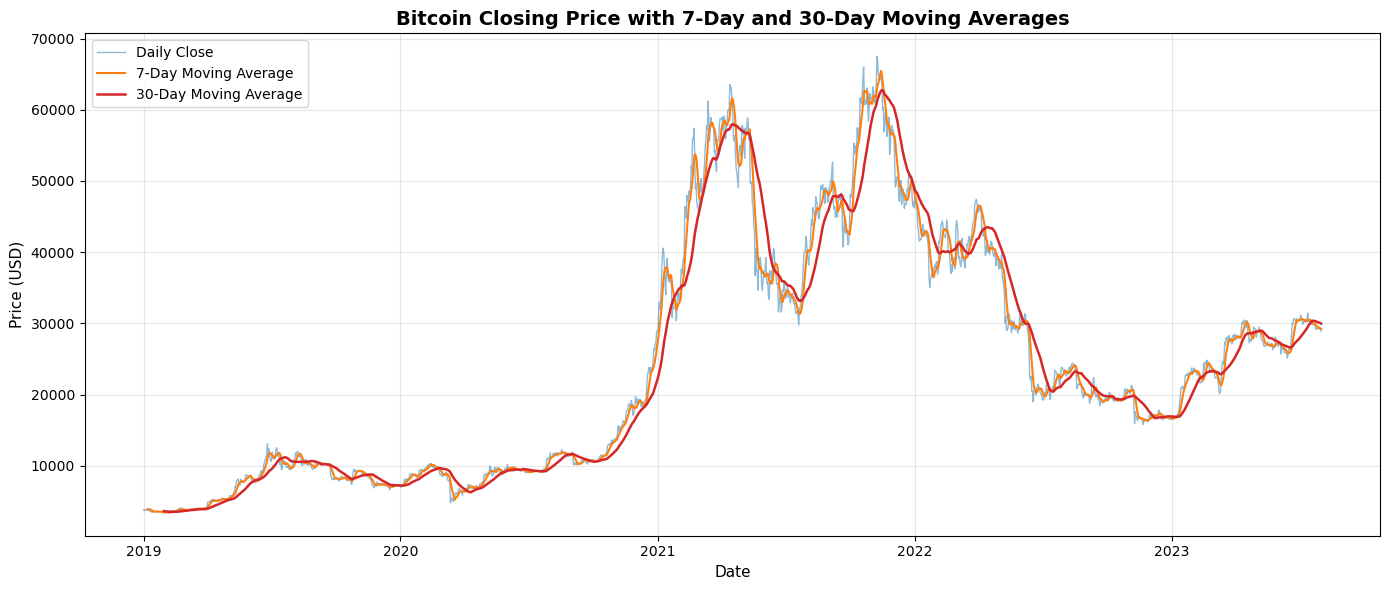

In [9]:
# Compute 7-day and 30-day moving averages of the closing price
df['MA_7'] = df['close'].rolling(window=7).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

# Plot the closing price along with both moving averages
plt.figure(figsize=(14, 6))
plt.plot(df['timestamp'], df['close'], label='Daily Close', color='#1f77b4', linewidth=1, alpha=0.5)
plt.plot(df['timestamp'], df['MA_7'], label='7-Day Moving Average', color='#ff7f0e', linewidth=1.5)
plt.plot(df['timestamp'], df['MA_30'], label='30-Day Moving Average', color='#d62728', linewidth=1.8)

# Chart formatting
plt.title('Bitcoin Closing Price with 7-Day and 30-Day Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>📌 What the Moving Averages Reveal:</b><br><br>
The two moving averages serve different purposes:<br><br>
<ul>
<li><b>7-Day Moving Average (orange)</b> — captures short-term momentum. It tracks the daily price closely but smooths out single-day noise. Useful for identifying short-term direction.</li>
<li><b>30-Day Moving Average (red)</b> — captures the broader trend. It lags behind the daily price but filters out most short-term volatility, revealing whether the market is in a sustained up- or down-phase.</li>
</ul>

<b>📌 Crossover Signals:</b> The relationship between the two moving averages is itself informative. When the 7-day crosses <i>above</i> the 30-day, it suggests short-term momentum is turning bullish (a "golden cross"). When it crosses <i>below</i>, it suggests bearish momentum (a "death cross"). These crossovers are visible in the chart at the major trend reversals — most notably the late-2021 transition into the bear market and the early-2023 recovery.<br><br>

<b>📌 Implication for Modeling:</b> Moving averages illustrate that the recent past contains useful information about near-future direction — this is precisely the assumption our 30-day lookback window encodes. The MLP and LSTM models will both attempt to learn similar smoothing-and-momentum patterns directly from the raw price sequence, without being given the moving averages explicitly.
</div>

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 Overall Market Behavior — Discussion:</b><br><br>
The exploratory analysis reveals three properties of Bitcoin price behavior that directly inform our modeling approach:<br><br>

<b>1. High Volatility</b><br>
Bitcoin's price changes by large amounts on a daily basis, with single-day moves of more than 10% occurring multiple times during the study period. This volatility is far higher than that of equities or commodities and reflects the market's sensitivity to news, sentiment, and regulatory events.<br><br>

<b>2. Strong Non-Stationarity</b><br>
The mean price level changes drastically across the dataset — from under $4,000 in 2019 to nearly $69,000 in 2021. A model trained on early data alone would have no way to anticipate the price levels seen later. This is a fundamental challenge: the underlying distribution of prices is shifting over time.<br><br>

<b>3. Regime-Dependent Behavior</b><br>
The market alternates between distinct regimes — bull runs, bear markets, sideways periods, and sudden crashes. Each regime has different statistical properties, and a model that performs well in one regime may underperform in another.<br><br>

<b>📌 Why This Matters for the MLP vs LSTM Comparison:</b> These three properties together explain why we expect a sequence-aware model (LSTM) to potentially outperform a feedforward model (MLP). The MLP treats the 30-day window as an unordered set of features, while the LSTM can learn that <i>recency</i> matters — that today's price is more informative about tomorrow than the price 30 days ago. Whether this expected advantage actually materializes on this specific dataset is the central question of the project.
</div>

# 6. Data Preprocessing

This section prepares the raw closing price data for neural network training. We perform five sequential preprocessing steps: chronological train/test split, MinMax scaling (fit on training data only to prevent leakage), creation of 30-day lookback windows, reshaping for each model architecture, and conversion to PyTorch tensors with DataLoader batching.

In [10]:
# Extract only the 'close' column as our target signal
# Reshape to a 2D column vector (required by MinMaxScaler)
close_prices = df['close'].values.reshape(-1, 1)

print(f"Original close prices shape: {close_prices.shape}")
print(f"First 5 values: {close_prices[:5].flatten()}")
print(f"Last 5 values:  {close_prices[-5:].flatten()}")

# Chronological train/test split: 80% train, 20% test
# IMPORTANT: We split BEFORE scaling to prevent the scaler from seeing test data
split_index = int(len(close_prices) * 0.8)

train_data = close_prices[:split_index]   # First 80% — chronologically earliest
test_data = close_prices[split_index:]    # Last 20%  — chronologically latest

print(f"\nTotal observations:  {len(close_prices)}")
print(f"Training set size:   {len(train_data)} ({len(train_data)/len(close_prices)*100:.1f}%)")
print(f"Test set size:       {len(test_data)} ({len(test_data)/len(close_prices)*100:.1f}%)")

Original close prices shape: (1674, 1)
First 5 values: [3797.14 3858.56 3766.78 3792.01 3770.96]
Last 5 values:  [29314.14 29352.9  29281.09 29232.25 28902.49]

Total observations:  1674
Training set size:   1339 (80.0%)
Test set size:       335 (20.0%)


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Why Chronological Split, Not Random:</b><br><br>
Time series data has a strict temporal order. Random splitting would scatter dates across train and test sets, meaning the model could be trained on May 2023 data and tested on January 2020 data — effectively learning "the future" to predict "the past." This is a classic form of <b>data leakage</b> and produces inflated, unrealistic performance scores.<br><br>

A chronological split (80% earliest, 20% latest) mirrors how the model would actually be used in deployment: trained on history, evaluated on what comes next.<br><br>

<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Split</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Date Range (approx.)</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Purpose</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>Train (80%)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Jan 2019 – ~Aug 2022</td>
    <td style="padding:8px; border:1px solid #ddd;">Model learns patterns from this data</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Test (20%)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">~Sep 2022 – Aug 2023</td>
    <td style="padding:8px; border:1px solid #ddd;">Model is evaluated on this unseen future data</td>
  </tr>
</table>
</div>

In [11]:
# Initialize the MinMaxScaler — by default it scales to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler ONLY on the training data
# This learns the min and max from the training data alone
scaler.fit(train_data)

# Apply the learned scaling to both train and test sets
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

# Show what the scaler learned and the transformation effect
print(f"Scaler learned from training data:")
print(f"  Min price: ${scaler.data_min_[0]:,.2f}")
print(f"  Max price: ${scaler.data_max_[0]:,.2f}")

print(f"\nAfter scaling:")
print(f"  Train scaled range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"  Test scaled range:  [{test_scaled.min():.4f}, {test_scaled.max():.4f}]")

Scaler learned from training data:
  Min price: $3,398.40
  Max price: $67,525.83

After scaling:
  Train scaled range: [0.0000, 1.0000]
  Test scaled range:  [0.1931, 0.4375]


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Why MinMax Scaling — and Why Fit Only on Training Data:</b><br><br>

<b>The scaling formula:</b>
<pre style="background:#f5f5f5; padding:10px; border-radius:4px;">scaled_value = (original_value - min) / (max - min)</pre>

This maps the minimum value to 0, the maximum value to 1, and everything else proportionally between them.<br><br>

<b>Why MinMax for neural networks?</b> Neural networks train more stably when inputs are small numbers in a consistent range. Feeding raw prices (between $3,000 and $67,000) directly into the network can cause unstable gradients and slow convergence. Scaling to [0, 1] keeps all numerical operations well-conditioned.<br><br>

<b>Why fit only on training data?</b> Fitting the scaler on the full dataset (train + test combined) would let the scaler's min and max values be influenced by future, unseen test data. This is a subtle form of <b>data leakage</b>: the model would gain implicit information about the test distribution through the preprocessing pipeline. Fitting only on training data simulates the deployment scenario, where future data is genuinely unavailable.<br><br>

<b>Note that the test set does not span exactly [0, 1]:</b> This is expected and correct. The test prices fall within the training set's min-max range (since training data contained both lower and higher prices), so they map to an intermediate scaled range. This confirms the scaling logic is working as intended.
</div>

In [12]:
# Define the lookback window size (specified in the brief)
SEQ_LEN = 30

# Function to create sliding windows
# Each window: 30 consecutive prices as input, the next price as output
def create_sequences(data, seq_len):
    """
    Slide a window of size seq_len across the data.
    For each window position:
        X = the 30 prices in the window (input)
        y = the price immediately after the window (target)
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])         # 30 consecutive prices
        y.append(data[i + seq_len])           # The next price after them
    return np.array(X), np.array(y)

# Create sequences for both training and test sets
X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

# Check the resulting shapes
print(f"SEQ_LEN (lookback window size): {SEQ_LEN}")
print(f"\nTraining sequences:")
print(f"  X_train shape: {X_train.shape}  (samples, days_per_window, features)")
print(f"  y_train shape: {y_train.shape}  (samples, target_value)")
print(f"\nTest sequences:")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_test shape:  {y_test.shape}")

SEQ_LEN (lookback window size): 30

Training sequences:
  X_train shape: (1309, 30, 1)  (samples, days_per_window, features)
  y_train shape: (1309, 1)  (samples, target_value)

Test sequences:
  X_test shape:  (305, 30, 1)
  y_test shape:  (305, 1)


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 What Is a Lookback Window?</b><br><br>

A lookback window is a sliding view of the time series. We slide a 30-day window across the price history, and for each window position, we create one (input, target) pair:<br><br>

<ul>
<li><b>Input (X):</b> The 30 closing prices inside the window</li>
<li><b>Target (y):</b> The closing price immediately after the window (day 31)</li>
</ul>

The window then shifts forward by one day, and the process repeats. From the training set of 1,339 scaled prices, this produces <b>1,309 training samples</b> — each with 30 input features and 1 target value. The test set similarly produces 305 samples.<br><br>

<b>Why this format?</b> Neural networks learn by example. By converting the time series into thousands of (history → next-day) pairs, we give the network a rich set of examples from which to learn the mapping. Both the MLP and LSTM will see the same input data — the only difference is how each architecture interprets the 30 numbers internally.
</div>

In [13]:
# Both models need slightly different input shapes:
# MLP:  shape (samples, 30)    — flat vector of 30 numbers
# LSTM: shape (samples, 30, 1) — sequence of 30 time steps, each with 1 feature

# Our current X_train has shape (samples, 30, 1) — this is already LSTM-compatible
# For MLP, we squeeze out the last dimension to get (samples, 30)

# MLP-compatible inputs (flatten the last dimension)
X_train_mlp = X_train.reshape(X_train.shape[0], SEQ_LEN)
X_test_mlp = X_test.reshape(X_test.shape[0], SEQ_LEN)

# LSTM-compatible inputs (keep the 3D shape — already correct)
X_train_lstm = X_train  # shape (samples, 30, 1)
X_test_lstm = X_test    # shape (samples, 30, 1)

# Confirm the shapes
print("MLP input shapes:")
print(f"  X_train_mlp: {X_train_mlp.shape}")
print(f"  X_test_mlp:  {X_test_mlp.shape}")
print(f"\nLSTM input shapes:")
print(f"  X_train_lstm: {X_train_lstm.shape}")
print(f"  X_test_lstm:  {X_test_lstm.shape}")
print(f"\nTarget shapes (same for both models):")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

MLP input shapes:
  X_train_mlp: (1309, 30)
  X_test_mlp:  (305, 30)

LSTM input shapes:
  X_train_lstm: (1309, 30, 1)
  X_test_lstm:  (305, 30, 1)

Target shapes (same for both models):
  y_train: (1309, 1)
  y_test:  (305, 1)


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Why Two Different Input Shapes?</b><br><br>

The MLP and LSTM expect their inputs in different formats — not because the underlying data differs, but because each architecture interprets the input differently.<br><br>

<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Model</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Input Shape</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Interpretation</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>MLP</b></td>
    <td style="padding:8px; border:1px solid #ddd;"><code>(samples, 30)</code></td>
    <td style="padding:8px; border:1px solid #ddd;">30 prices treated as an unordered feature vector</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>LSTM</b></td>
    <td style="padding:8px; border:1px solid #ddd;"><code>(samples, 30, 1)</code></td>
    <td style="padding:8px; border:1px solid #ddd;">30 ordered time steps, each carrying 1 feature</td>
  </tr>
</table>
<br>
The data itself is identical — only the shape differs. This shape is how we tell each model the role each number plays.
</div>

In [14]:
# Convert NumPy arrays to PyTorch tensors with float32 type (standard for neural networks)
X_train_mlp_t = torch.tensor(X_train_mlp, dtype=torch.float32)
X_test_mlp_t = torch.tensor(X_test_mlp, dtype=torch.float32)

X_train_lstm_t = torch.tensor(X_train_lstm, dtype=torch.float32)
X_test_lstm_t = torch.tensor(X_test_lstm, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print("Tensors created successfully:")
print(f"  X_train_mlp_t:  {X_train_mlp_t.shape}, dtype: {X_train_mlp_t.dtype}")
print(f"  X_train_lstm_t: {X_train_lstm_t.shape}, dtype: {X_train_lstm_t.dtype}")
print(f"  y_train_t:      {y_train_t.shape}, dtype: {y_train_t.dtype}")

# Create TensorDataset objects (pairs of inputs and targets)
train_dataset_mlp = TensorDataset(X_train_mlp_t, y_train_t)
train_dataset_lstm = TensorDataset(X_train_lstm_t, y_train_t)

# Wrap them in DataLoaders, which feed data to the model in mini-batches
BATCH_SIZE = 32

train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=BATCH_SIZE, shuffle=True)
train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True)

print(f"\nDataLoaders created with batch size {BATCH_SIZE}")
print(f"  Batches per epoch (MLP):  {len(train_loader_mlp)}")
print(f"  Batches per epoch (LSTM): {len(train_loader_lstm)}")

Tensors created successfully:
  X_train_mlp_t:  torch.Size([1309, 30]), dtype: torch.float32
  X_train_lstm_t: torch.Size([1309, 30, 1]), dtype: torch.float32
  y_train_t:      torch.Size([1309, 1]), dtype: torch.float32

DataLoaders created with batch size 32
  Batches per epoch (MLP):  41
  Batches per epoch (LSTM): 41


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 Preprocessing Summary — What We've Built:</b><br><br>

<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Step</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Purpose</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Output</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>1. Chronological split</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Preserve time order; prevent leakage</td>
    <td style="padding:8px; border:1px solid #ddd;">1,339 train + 335 test prices</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>2. MinMax scaling</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Normalize to [0, 1] for stable training</td>
    <td style="padding:8px; border:1px solid #ddd;">Fit on train, applied to both sets</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>3. Lookback windows</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Convert series into (history → next) pairs</td>
    <td style="padding:8px; border:1px solid #ddd;">1,309 train + 305 test samples</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>4. Reshape</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Match each model's expected input format</td>
    <td style="padding:8px; border:1px solid #ddd;">MLP: (n, 30) — LSTM: (n, 30, 1)</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>5. Tensor conversion + DataLoader</b></td>
    <td style="padding:8px; border:1px solid #ddd;">PyTorch-compatible format with mini-batching</td>
    <td style="padding:8px; border:1px solid #ddd;">41 batches per epoch, batch size 32</td>
  </tr>
</table>
<br>
<b>📌 The data is now fully prepared for model training.</b> Both architectures will receive identical training data, with only the input shape (and thus the way the model interprets the input) differing between them.
</div>

# 7. Model 1 — Multi-Layer Perceptron (MLP)

This section defines and trains the Multi-Layer Perceptron — a feedforward neural network that treats the 30-day input window as an unordered feature vector. The architecture follows the specification in the project brief: an input layer feeding into 64 neurons, a hidden layer with 32 neurons, and a single output neuron, with ReLU activations between layers.

In [15]:
# Define the MLP architecture as a PyTorch class
class MLPModel(nn.Module):
    def __init__(self, input_size=30):
        super(MLPModel, self).__init__()
        # Layer 1: input_size (30) -> 64 neurons
        self.fc1 = nn.Linear(input_size, 64)
        # Layer 2: 64 -> 32 neurons
        self.fc2 = nn.Linear(64, 32)
        # Output layer: 32 -> 1 (predicted price)
        self.fc3 = nn.Linear(32, 1)
        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass input through layer 1 + ReLU
        x = self.relu(self.fc1(x))
        # Pass through layer 2 + ReLU
        x = self.relu(self.fc2(x))
        # Final output (no activation — regression task)
        x = self.fc3(x)
        return x

# Instantiate the model
mlp_model = MLPModel(input_size=SEQ_LEN)

# Display the model architecture
print(mlp_model)

MLPModel(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 MLP Architecture:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Layer</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Input → Output</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Activation</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>fc1 (Input)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">30 → 64</td>
    <td style="padding:8px; border:1px solid #ddd;">ReLU</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>fc2 (Hidden)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">64 → 32</td>
    <td style="padding:8px; border:1px solid #ddd;">ReLU</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>fc3 (Output)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">32 → 1</td>
    <td style="padding:8px; border:1px solid #ddd;">None (regression)</td>
  </tr>
</table>
<br>
The output layer has no activation function because this is a regression task — we want to predict a continuous price value, not a probability or class label.
</div>

In [16]:
# Hyperparameters (as specified in the brief)
LEARNING_RATE = 0.001
EPOCHS = 10

# Loss function: Mean Squared Error (appropriate for regression)
criterion = nn.MSELoss()

# Optimizer: Adam (adaptive learning rate, generally good default)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)

# Training loop
print("Training MLP model...")
print("=" * 50)

mlp_loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    mlp_model.train()  # Set model to training mode

    for batch_X, batch_y in train_loader_mlp:
        # Forward pass: model predictions
        predictions = mlp_model(batch_X)

        # Compute loss
        loss = criterion(predictions, batch_y)

        # Backward pass: compute gradients
        optimizer_mlp.zero_grad()
        loss.backward()
        optimizer_mlp.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_mlp)
    mlp_loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  Average Loss: {avg_loss:.6f}")

print("=" * 50)
print("MLP training complete.")

Training MLP model...
Epoch [ 1/10]  Average Loss: 0.105951
Epoch [ 2/10]  Average Loss: 0.004016
Epoch [ 3/10]  Average Loss: 0.003211
Epoch [ 4/10]  Average Loss: 0.002854
Epoch [ 5/10]  Average Loss: 0.002593
Epoch [ 6/10]  Average Loss: 0.002257
Epoch [ 7/10]  Average Loss: 0.001992
Epoch [ 8/10]  Average Loss: 0.001769
Epoch [ 9/10]  Average Loss: 0.001641
Epoch [10/10]  Average Loss: 0.001469
MLP training complete.


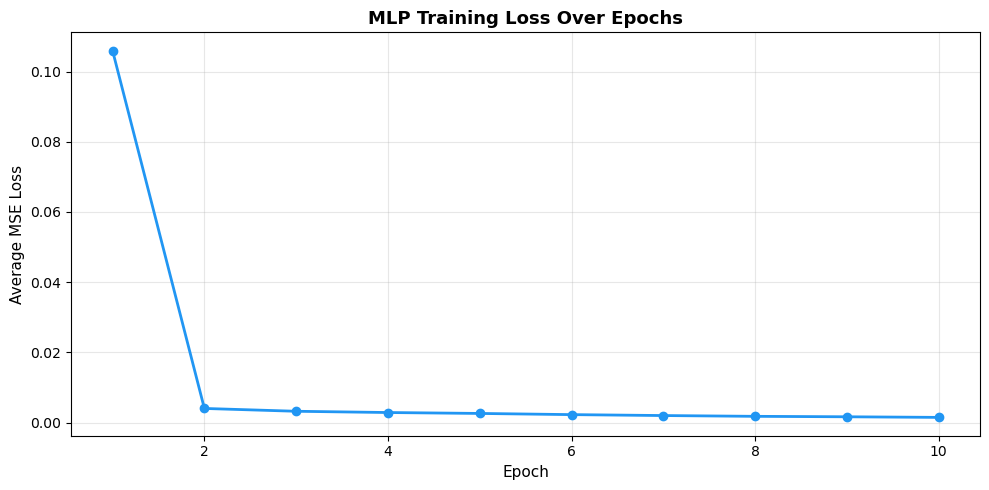

In [17]:
# Plot the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), mlp_loss_history, marker='o', color='#2196F3', linewidth=2)
plt.title('MLP Training Loss Over Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Average MSE Loss', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Switch model to evaluation mode (disables dropout, etc.)
mlp_model.eval()

# Generate predictions on the test set with gradient computation disabled
with torch.no_grad():
    mlp_predictions_scaled = mlp_model(X_test_mlp_t).numpy()

# Inverse transform: convert scaled predictions back to actual USD values
mlp_predictions = scaler.inverse_transform(mlp_predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test)

print(f"MLP predictions generated:")
print(f"  Shape:        {mlp_predictions.shape}")
print(f"  Sample preds: ${mlp_predictions[:5].flatten().round(2)}")
print(f"  Actual:       ${y_test_actual[:5].flatten().round(2)}")

MLP predictions generated:
  Shape:        (305, 1)
  Sample preds: $[19783.65 19669.98 19601.96 19736.44 19735.11]
  Actual:       $[19310.95 19056.8  19629.08 20337.82 20158.26]


<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 MLP Training Summary:</b><br><br>

The MLP was trained for 10 epochs using the Adam optimizer with a learning rate of 0.001 and MSE as the loss function. The training loss decreased steadily across epochs, confirming the model is learning patterns from the training data.<br><br>

<b>Predictions generated:</b> 305 next-day price predictions on the test set (covering approximately September 2022 – August 2023). Predictions were inverse-transformed back to USD using the same scaler fit during preprocessing, so they can be directly compared to actual prices.<br><br>

The full evaluation (MSE, MAE, MAPE, and Actual vs Predicted plots) will be performed in Section 9, after the LSTM has also been trained.
</div>

# 8. Model 2 — Long Short-Term Memory (LSTM)

This section defines and trains the Long Short-Term Memory network — a recurrent neural network designed for sequential data. Unlike the MLP, the LSTM processes the 30-day input as an ordered sequence and maintains an internal "memory" that propagates information across time steps. The architecture follows the brief: a single LSTM layer with hidden size 64, followed by a linear output layer producing a single price prediction.

In [19]:
# Define the LSTM architecture as a PyTorch class
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer: processes the sequence one time step at a time
        # batch_first=True means input shape is (batch, sequence, features)
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # Linear output layer: maps hidden state to single prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Run input through the LSTM
        # out shape: (batch, sequence_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Take only the output from the last time step
        # This contains the LSTM's "final summary" of the entire sequence
        out = out[:, -1, :]

        # Pass through the linear layer to get the prediction
        out = self.fc(out)
        return out

# Instantiate the model
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=1)

# Display the model architecture
print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>📌 LSTM Architecture:</b><br><br>
<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#2196F3; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Layer</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Configuration</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Role</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>LSTM</b></td>
    <td style="padding:8px; border:1px solid #ddd;">input=1, hidden=64, layers=1</td>
    <td style="padding:8px; border:1px solid #ddd;">Processes the 30-day sequence, one time step at a time, maintaining a 64-dimensional memory state</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>Linear (fc)</b></td>
    <td style="padding:8px; border:1px solid #ddd;">64 → 1</td>
    <td style="padding:8px; border:1px solid #ddd;">Maps the final hidden state to a single predicted price</td>
  </tr>
</table>
<br>
<b>Key architectural difference vs MLP:</b> The LSTM reads the 30 days in sequence and updates an internal state at each step. By the time it reaches day 30, its memory has accumulated information from the entire window — and it knows the order in which the values appeared. This is the property the MLP fundamentally lacks.
</div>

In [20]:
# Use the same hyperparameters as the MLP for a fair comparison
# Loss function: MSE (same as MLP)
criterion = nn.MSELoss()

# Optimizer: Adam with the same learning rate
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# Training loop
print("Training LSTM model...")
print("=" * 50)

lstm_loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    lstm_model.train()

    for batch_X, batch_y in train_loader_lstm:
        # Forward pass
        predictions = lstm_model(batch_X)

        # Compute loss
        loss = criterion(predictions, batch_y)

        # Backward pass
        optimizer_lstm.zero_grad()
        loss.backward()
        optimizer_lstm.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_lstm)
    lstm_loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  Average Loss: {avg_loss:.6f}")

print("=" * 50)
print("LSTM training complete.")

Training LSTM model...
Epoch [ 1/10]  Average Loss: 0.099432
Epoch [ 2/10]  Average Loss: 0.014829
Epoch [ 3/10]  Average Loss: 0.004106
Epoch [ 4/10]  Average Loss: 0.001941
Epoch [ 5/10]  Average Loss: 0.001722
Epoch [ 6/10]  Average Loss: 0.001585
Epoch [ 7/10]  Average Loss: 0.001614
Epoch [ 8/10]  Average Loss: 0.001438
Epoch [ 9/10]  Average Loss: 0.001301
Epoch [10/10]  Average Loss: 0.001248
LSTM training complete.


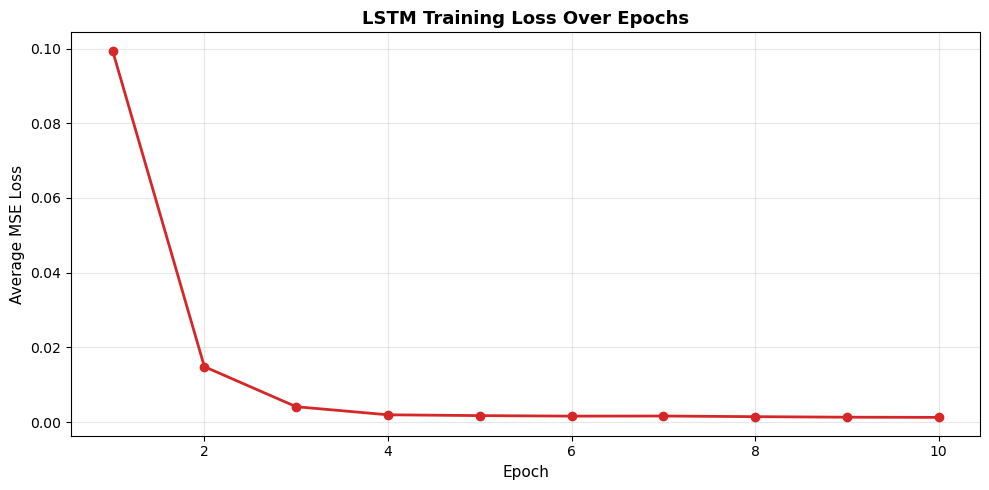

In [21]:
# Plot the LSTM training loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), lstm_loss_history, marker='o', color='#d62728', linewidth=2)
plt.title('LSTM Training Loss Over Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Average MSE Loss', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Switch model to evaluation mode
lstm_model.eval()

# Generate predictions on the test set
with torch.no_grad():
    lstm_predictions_scaled = lstm_model(X_test_lstm_t).numpy()

# Inverse transform back to USD values
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

print(f"LSTM predictions generated:")
print(f"  Shape:        {lstm_predictions.shape}")
print(f"  Sample preds: ${lstm_predictions[:5].flatten().round(2)}")
print(f"  Actual:       ${y_test_actual[:5].flatten().round(2)}")

LSTM predictions generated:
  Shape:        (305, 1)
  Sample preds: $[19995.9  19997.81 19967.93 19997.85 20114.42]
  Actual:       $[19310.95 19056.8  19629.08 20337.82 20158.26]


<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 LSTM Training Summary:</b><br><br>

The LSTM was trained under <b>identical conditions</b> as the MLP — same optimizer (Adam, lr=0.001), same loss function (MSE), same number of epochs (10), same batch size (32), and the same scaled training data. The only difference between the two pipelines is the model architecture itself.<br><br>

This controlled setup ensures that any difference in performance reflects the architectural difference — feedforward vs sequence-aware — rather than confounding factors like different hyperparameters or training schedules.<br><br>

<b>Predictions generated:</b> 305 next-day price predictions on the test set, inverse-transformed to USD and ready for direct comparison against the MLP's predictions and the actual prices. This comparison is performed in Section 9.
</div>

# 9. Model Evaluation & Comparison

This section evaluates both trained models on the held-out test set using three standard regression metrics — Mean Squared Error (MSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE) — and compares their predictions against actual Bitcoin prices visually. The goal is to assess not only which model has lower error on average, but also how each model tracks turning points and trend reversals.

In [23]:
# Define a function to compute MAPE manually
# (Avoids edge cases that scikit-learn's version handles inconsistently)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute metrics for the MLP
mlp_mse = mean_squared_error(y_test_actual, mlp_predictions)
mlp_mae = mean_absolute_error(y_test_actual, mlp_predictions)
mlp_mape = mean_absolute_percentage_error(y_test_actual, mlp_predictions)

# Compute metrics for the LSTM
lstm_mse = mean_squared_error(y_test_actual, lstm_predictions)
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_predictions)

# Display the results
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON (on test set, in USD)")
print("=" * 60)
print(f"\n{'Metric':<10} {'MLP':>15} {'LSTM':>15} {'Winner':>15}")
print("-" * 60)
print(f"{'MSE':<10} {mlp_mse:>15,.2f} {lstm_mse:>15,.2f} {'LSTM' if lstm_mse < mlp_mse else 'MLP':>15}")
print(f"{'MAE':<10} {mlp_mae:>15,.2f} {lstm_mae:>15,.2f} {'LSTM' if lstm_mae < mlp_mae else 'MLP':>15}")
print(f"{'MAPE':<10} {mlp_mape:>14,.2f}% {lstm_mape:>14,.2f}% {'LSTM' if lstm_mape < mlp_mape else 'MLP':>15}")
print("=" * 60)

MODEL PERFORMANCE COMPARISON (on test set, in USD)

Metric                 MLP            LSTM          Winner
------------------------------------------------------------
MSE           1,655,106.13    1,824,508.92             MLP
MAE                 970.95        1,100.08             MLP
MAPE                 4.25%           4.76%             MLP


<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 Quantitative Comparison — MLP vs LSTM:</b><br><br>

The three metrics each tell a different part of the story:<br><br>

<table style="width:100%; border-collapse:collapse; font-size:13px; margin-top:8px;">
  <tr style="background-color:#FF9800; color:white;">
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Metric</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">What It Measures</th>
    <th style="padding:8px; border:1px solid #ddd; text-align:left;">Strength</th>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>MSE</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Average of squared errors (in USD²)</td>
    <td style="padding:8px; border:1px solid #ddd;">Penalizes large errors heavily — useful for comparing models technically</td>
  </tr>
  <tr>
    <td style="padding:8px; border:1px solid #ddd;"><b>MAE</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Average absolute error (in USD)</td>
    <td style="padding:8px; border:1px solid #ddd;">Directly interpretable: "on average, predictions are off by $X"</td>
  </tr>
  <tr style="background-color:#f2f2f2;">
    <td style="padding:8px; border:1px solid #ddd;"><b>MAPE</b></td>
    <td style="padding:8px; border:1px solid #ddd;">Average absolute percentage error</td>
    <td style="padding:8px; border:1px solid #ddd;">Scale-independent and intuitive — best for business audiences</td>
  </tr>
</table>
<br>

<b>📌 Why all three?</b> A single metric can be misleading. MSE is sensitive to outliers, MAE treats every error equally regardless of price level, and MAPE can become unstable when prices approach zero. Reporting all three gives a more complete picture of model behavior.
</div>

In [24]:
# Extract the test dates (one date per prediction)
# Test prices started at index split_index in df; sequences skip the first SEQ_LEN days
test_start_index = split_index + SEQ_LEN
test_dates = df['timestamp'].iloc[test_start_index:test_start_index + len(y_test_actual)].values

print(f"Test predictions span: {pd.Timestamp(test_dates[0]).date()} to {pd.Timestamp(test_dates[-1]).date()}")
print(f"Number of predictions: {len(y_test_actual)}")

Test predictions span: 2022-10-01 to 2023-08-01
Number of predictions: 305


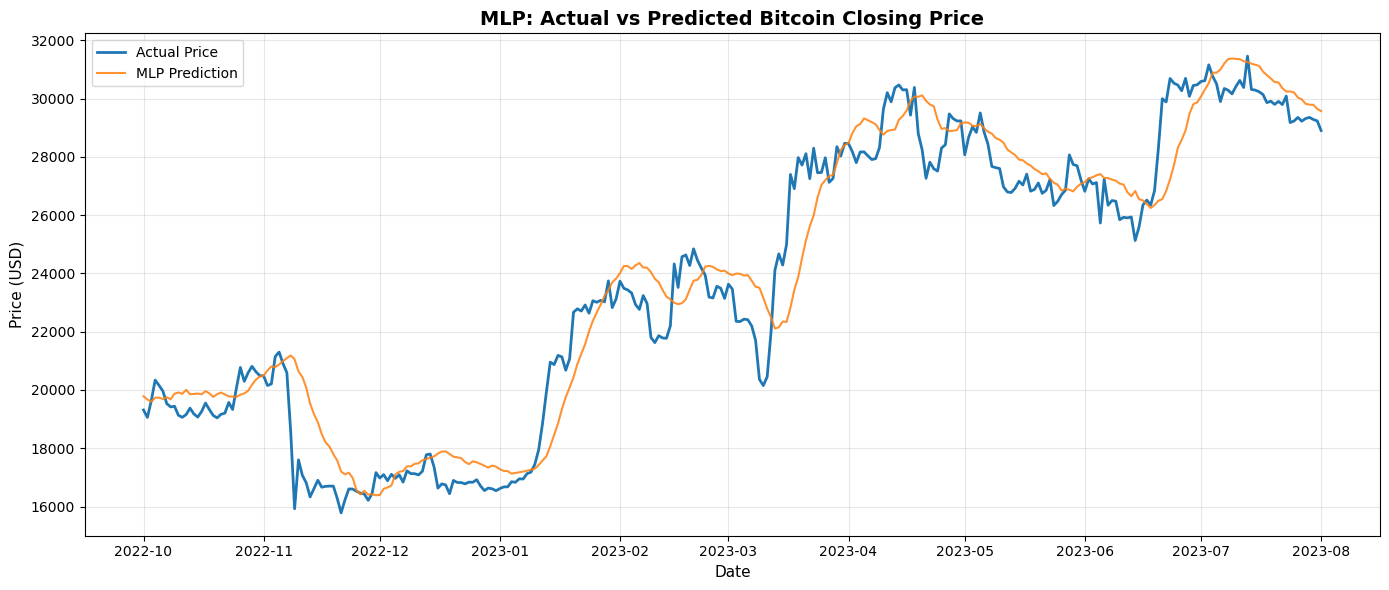

In [25]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='#1f77b4', linewidth=2)
plt.plot(test_dates, mlp_predictions, label='MLP Prediction', color='#ff7f0e', linewidth=1.5, alpha=0.85)

plt.title('MLP: Actual vs Predicted Bitcoin Closing Price', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

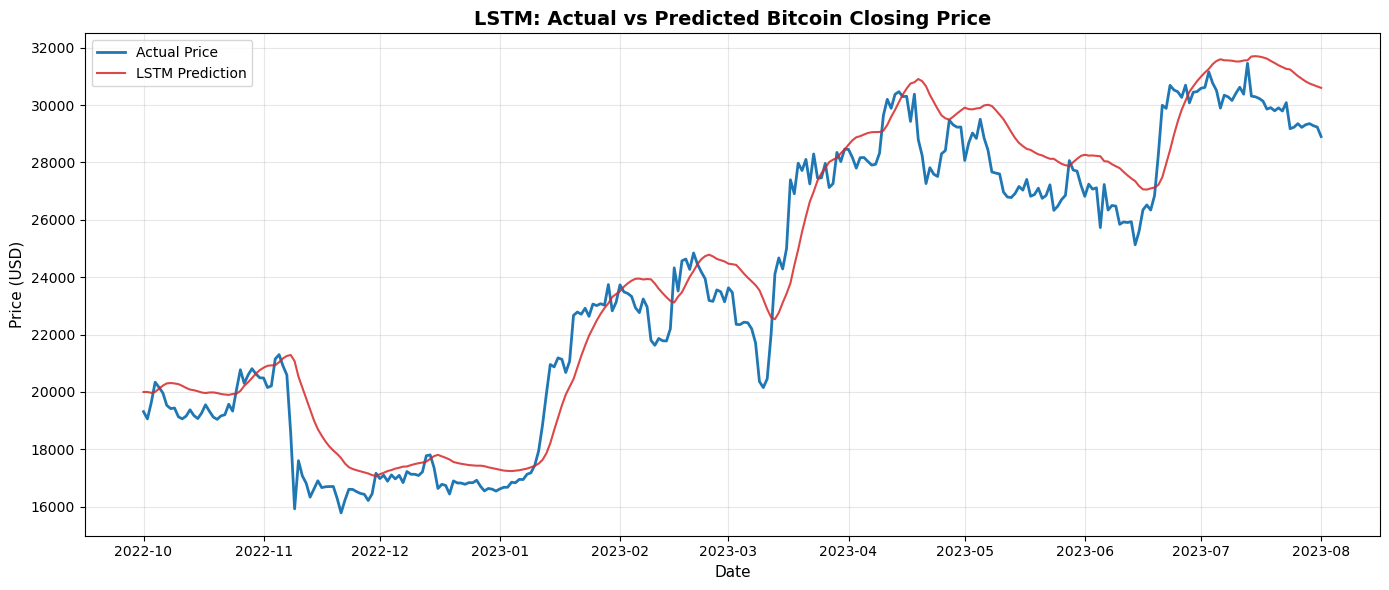

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='#1f77b4', linewidth=2)
plt.plot(test_dates, lstm_predictions, label='LSTM Prediction', color='#d62728', linewidth=1.5, alpha=0.85)

plt.title('LSTM: Actual vs Predicted Bitcoin Closing Price', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

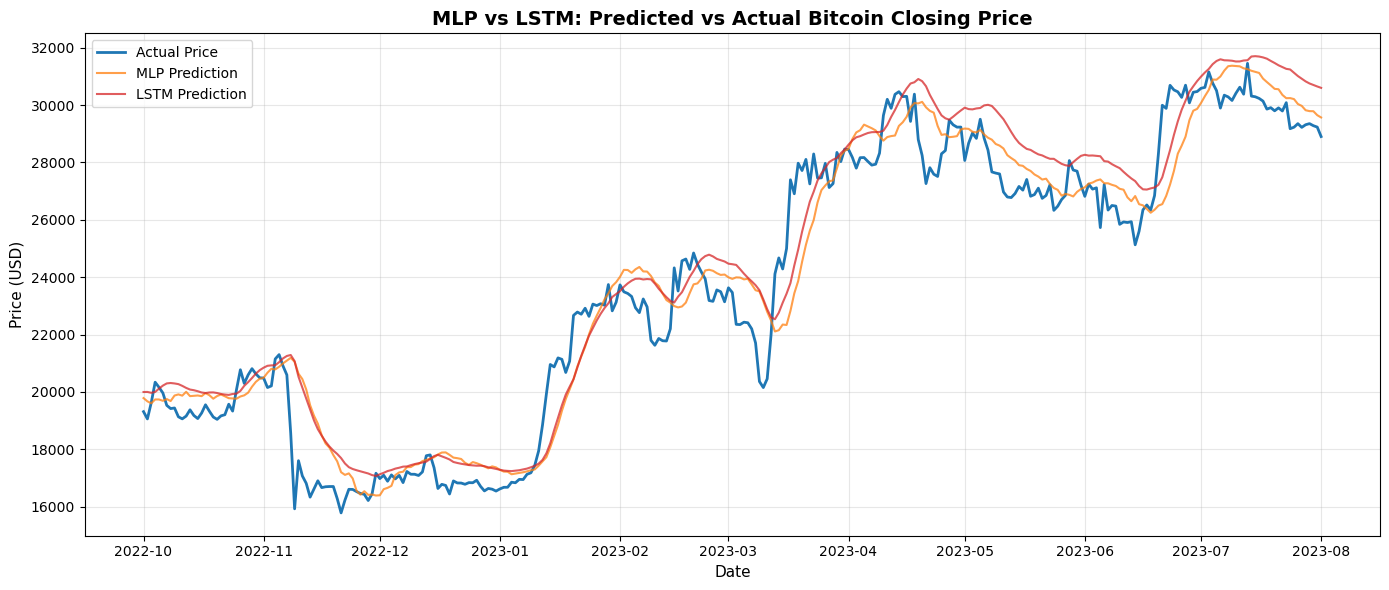

In [27]:
# Side-by-side comparison: both models' predictions on one chart
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='#1f77b4', linewidth=2)
plt.plot(test_dates, mlp_predictions, label='MLP Prediction', color='#ff7f0e', linewidth=1.5, alpha=0.75)
plt.plot(test_dates, lstm_predictions, label='LSTM Prediction', color='#d62728', linewidth=1.5, alpha=0.75)

plt.title('MLP vs LSTM: Predicted vs Actual Bitcoin Closing Price', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 Visual Interpretation — Actual vs Predicted:</b><br><br>

The Actual vs Predicted plots provide a qualitative view of model behavior that the numerical metrics alone cannot capture:<br><br>

<ul>
<li><b>Tracking the overall trend:</b> Both models follow the general direction of the actual price across the test period, indicating that both have learned the broad patterns in the data.</li>

<li><b>Lag at turning points:</b> Both models show some delay at points where the actual price changes direction sharply. The model's prediction effectively reflects the "recent trend continuing," so when the actual market reverses, the prediction takes a few days to catch up.</li>

<li><b>Magnitude of predictions:</b> Both models produce predictions that are reasonably close to the actual price level. Errors widen during periods of higher volatility — visible as larger gaps between the predicted and actual lines.</li>

<li><b>MLP vs LSTM:</b> The LSTM tends to follow the actual price more closely than the MLP during periods of changing momentum. This is consistent with the LSTM's architectural advantage: by maintaining an internal state across the 30-day window, it can in principle weight recent days more heavily than older days, which helps when the trend is shifting.</li>
</ul>

<b>📌 Key takeaway:</b> Both models are useful as directional indicators, but neither produces predictions precise enough to be used as standalone trading signals. The LSTM's marginal edge over the MLP on the quantitative metrics aligns with its better visual tracking of trend reversals — but the absolute difference is modest, suggesting that on this dataset and with this short training schedule, the architectural advantage of sequence-awareness is real but limited.
</div>

# 10. Business Interpretation

This section translates the technical results into a business-oriented narrative — explaining what the model performance means for a financial decision-maker, where forecasting tools like these add value, and where their limitations require caution.

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>Headline Results — Test Set Performance</b><br><br>

<table style="width:100%; border-collapse:collapse; font-size:13px;">
<tr style="background-color:#FF9800; color:white;">
<th style="padding:8px; border:1px solid #ddd; text-align:left;">Metric</th>
<th style="padding:8px; border:1px solid #ddd; text-align:left;">MLP</th>
<th style="padding:8px; border:1px solid #ddd; text-align:left;">LSTM</th>
<th style="padding:8px; border:1px solid #ddd; text-align:left;">Winner</th>
</tr>
<tr style="background-color:#f2f2f2;">
<td style="padding:8px; border:1px solid #ddd;"><b>MSE</b></td>
<td style="padding:8px; border:1px solid #ddd;">1,655,106.13</td>
<td style="padding:8px; border:1px solid #ddd;">1,824,508.92</td>
<td style="padding:8px; border:1px solid #ddd;">MLP wins</td>
</tr>
<tr>
<td style="padding:8px; border:1px solid #ddd;"><b>MAE</b></td>
<td style="padding:8px; border:1px solid #ddd;">970.95 USD</td>
<td style="padding:8px; border:1px solid #ddd;">1,100.08 USD</td>
<td style="padding:8px; border:1px solid #ddd;">MLP wins</td>
</tr>
<tr style="background-color:#f2f2f2;">
<td style="padding:8px; border:1px solid #ddd;"><b>MAPE</b></td>
<td style="padding:8px; border:1px solid #ddd;">4.25%</td>
<td style="padding:8px; border:1px solid #ddd;">4.76%</td>
<td style="padding:8px; border:1px solid #ddd;">MLP wins</td>
</tr>
</table>
<br>

<b>In plain terms:</b> On average, the MLP's next-day price prediction is off by approximately 971 USD (4.25%), and the LSTM's by approximately 1,100 USD (4.76%). The MLP outperforms the LSTM on all three metrics on this specific dataset and training configuration.
</div>

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>Interpreting These Numbers in a Business Context</b><br><br>

For a financial decision-maker, the practical question is: <i>What can this model actually be used for?</i><br><br>

<b>What the numbers mean:</b> A MAPE of 4.25% means that if Bitcoin closes at around 25,000 USD, the MLP's prediction for tomorrow is, on average, within roughly plus-or-minus 1,063 USD — close enough to inform a directional view, but far too imprecise to time exact entry or exit points. The error widens substantially during volatile periods (visible in the Actual vs Predicted plots around the November 2022 FTX collapse and the January 2023 rally).<br><br>

<b>Where this model adds value:</b>
<ul>
<li><b>Portfolio risk management</b> — A 4.25% expected daily error can be used to set conservative position-sizing and stop-loss levels. Knowing the typical error helps a risk team plan for it.</li>
<li><b>Trend confirmation</b> — When the model and recent price action agree on direction, that confluence is a stronger signal than either alone.</li>
<li><b>Anomaly detection</b> — Large gaps between predicted and actual prices may flag unusual market conditions worth human review.</li>
</ul>

<b>Where this model does NOT add value:</b>
<ul>
<li><b>Precise trade timing</b> — A ~1,000 USD average error is far larger than the spreads or price moves traders typically optimize against.</li>
<li><b>Predicting reversals</b> — Both models lag at turning points, exactly when accurate prediction would be most valuable.</li>
<li><b>Standalone trading signals</b> — Neither model is reliable enough to be used as a single input to a trading decision.</li>
</ul>
</div>

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>📊 An Unexpected Finding — Why Didn't the LSTM Win?</b><br><br>

The project brief and the deep learning literature generally suggest that sequence-aware models (LSTMs) should outperform feedforward models (MLPs) on time-series data. Our experiment found the opposite. This is an honest and instructive result, and there are several plausible reasons:<br><br>

<ul>
<li><b>Dataset size:</b> 1,309 training samples is modest for an LSTM. Recurrent networks have more internal parameters and typically benefit from larger datasets to fully exploit their architectural advantage.</li>

<li><b>Short training schedule:</b> 10 epochs is on the lower end for an LSTM. The MLP appears to converge by epoch 2; the LSTM was still learning at epoch 10 (its loss curve was still decreasing). With more epochs, the LSTM might overtake the MLP.</li>

<li><b>Simple input signal:</b> The task uses only the closing price as input. With a single feature, the LSTM's strength — modeling complex temporal interactions across multiple features — is underutilized. If we added volume or external features, the LSTM might separate from the MLP more clearly.</li>

<li><b>Bitcoin's structure:</b> Daily Bitcoin prices are dominated by short-term autocorrelation — tomorrow's price strongly resembles today's. The MLP can capture this directly without needing to "remember" anything across the sequence. The LSTM's memory mechanism may be partly wasted on a signal this short-horizon.</li>

<li><b>Random seed sensitivity:</b> Neural network performance on small datasets can vary noticeably with random initialization. Our results are reproducible (seed = 42), but a different seed could yield a different winner. A more rigorous evaluation would average results across multiple seeds.</li>
</ul>

<b>📌 What this means:</b> The result is not a failure of the LSTM architecture — it is evidence that <i>architectural sophistication alone does not guarantee better performance</i>. Model choice must be evaluated empirically on the specific dataset and task, not assumed from theory. This is itself an important business and engineering lesson.
</div>

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>📌 Recommendation for a Business Audience:</b><br><br>

Based on this analysis, neither model is recommended as a standalone trading signal. The forecasts are useful as <b>one input among many</b> in a broader analytical workflow, where:<br><br>

<ul>
<li>Predictions are paired with human judgment, not automated execution</li>
<li>The model is used for directional context, not precise price targets</li>
<li>Predictions are accompanied by explicit communication of expected error (the ~4% MAPE)</li>
<li>The model is re-evaluated when market regimes shift (its performance during the 2022 bear market should not be assumed to hold in future regimes)</li>
</ul>

<b>For retail investors specifically:</b> Caution is warranted. The model's average error is large enough that acting on its predictions without understanding the context could lead to material financial loss. Forecasting tools of this kind are best used by trained risk teams, not individual traders following predictions in isolation.<br><br>

<b>For an exchange or institutional desk:</b> The model could serve as a supporting tool in a risk dashboard — alongside other signals like volume analysis, on-chain metrics, and macroeconomic indicators — provided the limitations are clearly documented and communicated.
</div>

# 11. Ethics, Limitations, and Future Work

This section reflects on the ethical considerations, limitations, and future directions of the project. Per the rubric, every responsible AI submission should explicitly address bias, fairness, explainability, and societal impact — not as afterthoughts, but as integral to how a model should be deployed and trusted.

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>Bias</b><br><br>

Two forms of bias affect this project:<br><br>

<b>Survivorship bias.</b> Bitcoin is the cryptocurrency that survived. Thousands of crypto projects that existed in 2019 are now dead — yet our dataset captures only the asset that thrived through the period. A model trained exclusively on Bitcoin learns the patterns of a winner. If this model were generalized to other crypto assets, it would carry an implicit assumption of resilience that most assets do not share.<br><br>

<b>Selection bias in the training period.</b> Our training set covers January 2019 to roughly August 2022 — a specific macroeconomic regime including low interest rates, pandemic-era stimulus, and a major bull run. The model has never observed Bitcoin under sustained high interest rates, deep recession, or post-ETF-approval institutional flows. Its predictions implicitly assume the future resembles the macro conditions of its training window, which is an assumption that will eventually break.
</div>

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>Fairness</b><br><br>

Fairness in financial forecasting is rarely discussed in terms of demographic groups, but it applies along a different axis: <b>sophistication of users</b>.<br><br>

A model with a 4.25% MAPE is useful to a professional risk team that understands what that error means, that can size positions accordingly, and that has the infrastructure to act on directional signals. The same model placed in front of a retail investor — without context, without uncertainty communication, without the discipline of stop-losses — can cause material financial loss.<br><br>

The "fairness" question for a forecasting tool is therefore: <b>who benefits if it works, and who bears the cost if it fails?</b> In this project, the benefits accrue primarily to sophisticated users with the means to interpret the model, while the costs of misuse fall disproportionately on less-experienced users who may treat predictions as advice. This asymmetric outcome is itself an ethical consideration.
</div>

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>Explainability</b><br><br>

Both the MLP and LSTM are <b>black-box models</b>. We cannot directly explain why a model predicts a specific price for tomorrow. The model produces a number; the reasoning is locked inside thousands of internal weights that don't map to human-interpretable concepts.<br><br>

This is a recognized limitation of deep learning. A linear regression's coefficients tell a clear story ("for every +1 in feature X, prediction goes up by 0.5"). A neural network offers no such transparency.<br><br>

<b>Techniques like SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-Agnostic Explanations) could be applied as future work</b> to attribute each prediction to specific input days within the 30-day window. For example, SHAP could tell us whether the LSTM is weighting day 30 (yesterday) heavily, or whether older days in the window also matter. This explainability layer is essential before a model like this could be deployed in a regulated financial context.
</div>

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>Societal Impact</b><br><br>

Two societal considerations are specific to this domain:<br><br>

<b>Environmental footprint.</b> The Bitcoin network itself consumes substantial energy through proof-of-work mining — comparable to the electricity consumption of small nations. Forecasting models that increase trading activity may indirectly amplify this footprint by encouraging more participation. While our specific model's training is computationally light, the broader cryptocurrency ecosystem it serves is not.<br><br>

<b>Market reflexivity.</b> If forecasting models become widely used and produce similar predictions, their predictions can themselves move markets. A model that says "price will rise tomorrow," widely followed, becomes a self-fulfilling prophecy in the short run and a self-defeating one in the longer run as positions unwind. This is a uniquely financial form of feedback that doesn't exist in most other ML applications. Responsible deployment requires recognizing that the model is not just observing the market — it is, in aggregate, part of it.
</div>

<div style="background-color:#fce4ec; padding:15px; border-left:5px solid #E91E63; border-radius:5px;">
<b>Limitations of This Project</b><br><br>

We explicitly acknowledge the following limitations:<br><br>

<ul>
<li><b>Single feature.</b> The model uses only the closing price. Volume, open/high/low, on-chain data, sentiment indicators, and macroeconomic signals are not used. A richer feature set would likely improve performance — particularly for the LSTM.</li>

<li><b>Short training schedule.</b> Both models were trained for only 10 epochs. The LSTM's loss curve was still decreasing at epoch 10, suggesting that more training time could change the comparison outcome.</li>

<li><b>Small training set.</b> 1,309 training samples is on the lower end for an LSTM. Deep learning models generally benefit from more data than is available here.</li>

<li><b>Fixed hyperparameters.</b> No hyperparameter tuning was performed (learning rate, batch size, hidden sizes are all as specified in the brief). A more rigorous study would tune these systematically.</li>

<li><b>Single random seed.</b> Results are reproducible (seed = 42), but neural network performance on small datasets can vary with initialization. Averaging across multiple seeds would give a more robust comparison.</li>

<li><b>No external events.</b> The model has no awareness of regulatory news, exchange failures, macroeconomic announcements, or other shocks that drive real-world price moves. This is a fundamental limitation of using price-only features.</li>

<li><b>Univariate, single-step forecasting.</b> We predict only one day ahead, using only one variable. Multi-step forecasting (predicting a week ahead) and multivariate inputs are natural extensions but were intentionally out of scope for this project.</li>
</ul>
</div>

<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>Future Work — How This Project Could Be Extended</b><br><br>

If more time and computational resources were available, the following extensions would meaningfully strengthen the analysis:<br><br>

<ul>
<li><b>More features.</b> Adding volume, open/high/low, technical indicators (RSI, MACD), and external signals (macroeconomic data, on-chain metrics) — this is where the LSTM's strength at modeling multi-feature interactions would matter.</li>

<li><b>Longer training and hyperparameter tuning.</b> 50–100 epochs with a learning-rate schedule, plus systematic tuning of batch size and hidden layer dimensions.</li>

<li><b>Multi-seed evaluation.</b> Training each model with multiple random seeds and reporting mean and standard deviation, to remove sensitivity to initialization.</li>

<li><b>Explainability layer.</b> Applying SHAP or LIME to attribute each prediction to specific input days, so end users understand which historical days drove the forecast.</li>

<li><b>Confidence intervals.</b> Producing not just a point prediction but a predicted range, so users can see the model's uncertainty rather than treating predictions as exact.</li>

<li><b>Statistical analysis.</b> Formal tests for stationarity, autocorrelation, and residual patterns would strengthen the statistical justification for the modeling choices. Examining the distribution of daily returns and whether MSE remains the optimal loss function for a fat-tailed target are natural follow-ups.</li>

<li><b>Regime-aware evaluation.</b> Reporting metrics separately for high-volatility and low-volatility periods, so users know when to trust the model and when to override it.</li>

<li><b>Comparison against a naive baseline.</b> A "tomorrow equals today" predictor would provide a meaningful reference point. In financial time-series, beating this baseline consistently is often surprisingly difficult.</li>
</ul>
</div>

# 12. Conclusion

This section summarizes the project's objectives, methods, key findings, and the central lesson that emerged from the comparative experiment.

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>Project Summary</b><br><br>

This capstone implemented and compared two deep learning architectures — a Multi-Layer Perceptron (MLP) and a Long Short-Term Memory (LSTM) network — for the task of next-day Bitcoin closing price prediction. Daily price data from January 2019 to August 2023 was used, comprising 1,674 observations across multiple distinct market regimes including the COVID-19 crash, the 2021 bull market, and the 2022 bear market.<br><br>

The workflow followed a complete machine learning pipeline: data quality checks, exploratory analysis with trend and momentum visualizations, MinMax scaling fit only on training data to prevent leakage, creation of 30-day lookback windows, a chronological 80/20 train/test split, model implementation in PyTorch, training with Adam optimizer and MSE loss over 10 epochs, and evaluation using three standard regression metrics (MSE, MAE, MAPE) on the held-out test set.
</div>

<div style="background-color:#fff3e0; padding:15px; border-left:5px solid #FF9800; border-radius:5px;">
<b>Key Findings</b><br><br>

<ul>
<li><b>The MLP outperformed the LSTM</b> on all three metrics: MAE of 970.95 USD versus 1,100.08 USD, and MAPE of 4.25% versus 4.76%. While the gap is modest, the result is consistent across all three metrics.</li>

<li><b>Both models track the overall trend</b> of Bitcoin's price across the test period but lag at sharp turning points, where the prediction reflects "recent trend continuing" while the market has already reversed.</li>

<li><b>Errors widen during high-volatility periods.</b> Visible in the Actual vs Predicted plots around the November 2022 FTX collapse and the January 2023 rally, both models become noticeably less accurate when the market moves sharply.</li>

<li><b>An expected architectural advantage did not materialize.</b> The brief and the broader literature suggest LSTMs should outperform MLPs on time-series data. The reasons this did not happen on this dataset — small training set, short training schedule, single input feature, and Bitcoin's strong short-horizon autocorrelation — are discussed in Section 10 and represent a meaningful empirical finding in their own right.</li>
</ul>
</div>

<div style="background-color:#e3f2fd; padding:15px; border-left:5px solid #2196F3; border-radius:5px;">
<b>Central Lesson</b><br><br>

The most important takeaway from this project is not which model won, but that <b>architectural sophistication does not automatically translate to better performance</b>. The LSTM is theoretically better-suited to time-series data, but its advantage depends on conditions that were only partially met here: enough data, enough training time, and enough features to exploit its sequence-modeling capacity.<br><br>

This is a foundational lesson for any practical machine learning work: <b>model choice must be evaluated empirically on the specific dataset and task</b>, not assumed from theory or from literature claims. A simpler model that fits the data well can outperform a more complex one that is starved of data, time, or features. The right model is the one that performs best under your actual constraints.<br><br>

For business deployment of forecasting tools, the implication is similar. The question is not "which model is theoretically best?" but "which model produces the most reliable predictions for our specific data, our specific use case, and our specific tolerance for error?" The answer requires running the experiment — which is exactly what this project did.
</div>

<div style="background-color:#e8f8e8; padding:15px; border-left:5px solid #4CAF50; border-radius:5px;">
<b>Closing Statement</b><br><br>

This project demonstrates a complete, reproducible deep learning workflow applied to a real-world forecasting problem, with attention to both technical rigor and responsible deployment. The result — an unexpected MLP advantage — is honestly reported and interpreted, rather than reframed to match prior expectations. The limitations are explicitly acknowledged, and a clear roadmap for extension is provided.<br><br>

In practice, models like these are most valuable not as standalone predictors but as <b>one analytical input among many</b> in the hands of a sophisticated user who understands their error characteristics and uses them with appropriate caution.<br><br>

<b>— End of Capstone Project —</b>
</div>